# Scaled Hermite approximations for various target functions

Let's start by loading necessary libraries.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import jax 
from jax import numpy as jnp
from flows.types import *
import optax
from flows.utils import *
from flows.models.linear import Linear
from flows.utils import *
import matplotlib.pyplot as plt
from functools import partial
from flows.Bases import Hermite 
from flows.bases import *
import flax.linen as nn
import sys 
import math
import pickle 
from sklearn.linear_model import LinearRegression
from target_functions import *
jax.config.update("jax_enable_x64", True)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Computer Modern Roman'
fontsize_label = 18
fontsize_title = fontsize_label + 1
fontsize_legend = fontsize_label - 4
# size of the ticks 
plt.rcParams['xtick.labelsize'] = fontsize_label - 5
plt.rcParams['ytick.labelsize'] = fontsize_label - 5

print(f"available devices: {jax.devices()}")

available devices: [CpuDevice(id=0)]


## Approximating algebraically decaying function

In [48]:
f = f_algebraic

x = jnp.linspace(-30.999,30.999,10000)

w = np.zeros_like(x)
dx = np.diff(x)
w[1:-1] = (dx[:-1] + dx[1:])/2
w[0] = dx[0]/2
w[-1] = dx[-1]/2
x = x[:,None]

f_ev = f(x, w)
integral = jnp.einsum('j,j->', f_ev, w)
print(f_ev[-1], integral)

2.0727462290778044e-24 0.9999999999999961


Define a Gaussian density

In [49]:
def Gaussian(x):
    return (jnp.exp(-x[:,0]**2)/jnp.sqrt(jnp.pi))[:, None]

integral_Gaussian = jnp.einsum('j,j->', Gaussian(x)[:,0], w)
print(integral_Gaussian)

1.0


Define a scaling and shifting model and make sure it is invertible

In [50]:
class Lin(nn.Module):
    dim: int

    def setup(self):
        self.lin_model = Linear([1.], [0.])
 
    @nn.compact
    def __call__(self, x, mode=evaluationMode.direct):
        x = jnp.array(x)
        if mode == evaluationMode.direct:
            return self.lin_model(x)
        else:
            return self.lin_model(x, mode="inverse")

model = Lin(x.shape[1])
params = model.init(jax.random.PRNGKey(0), x, mode=evaluationMode.inverse)
y_forward = model.apply(params, x, mode=evaluationMode.inverse)
y_forward_back = model.apply(params, y_forward, mode=evaluationMode.direct)
print(f"diff: {jnp.amax(jnp.abs(x-y_forward_back))}")

diff: 0.0


Optimize the scaling and shifting parameters

In [51]:
params = model.init(jax.random.PRNGKey(0), x, mode=evaluationMode.direct)
y_forward = model.apply(params, x, mode=evaluationMode.inverse)
y_forward_back = model.apply(params, y_forward, mode=evaluationMode.direct)

@jax.jit
def l2_error(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values, w))
    return loss

# another loss to punish more deviations in the tail 
@jax.jit
def error_tail(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values*(1+x[:,0]**2 / (true_func + 1e-30)), w))
    return loss

def total_loss(params, x, w, alpha=0.9):
    return alpha*l2_error(params, x, w) + (1-alpha)*error_tail(params, x, w)

nograd = lambda x: jax.lax.stop_gradient(x)
loss_grad_fn = jax.value_and_grad(total_loss)
loss_fn = total_loss

@jax.jit
def update_params(carry, args):
    params, opt_state, loss = carry
    loss_val, grad = loss_grad_fn(params, *args)
    updates, opt_state = optimizer.update(grad, opt_state)
    params = optax.apply_updates(params, updates)

    return (params, opt_state, loss+loss_val), 0

learning_rate = 1e-2
n_epochs = 1000
nmax = 0


schedule = optax.cosine_decay_schedule(learning_rate, n_epochs, alpha=5e-5/learning_rate)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(schedule),
)
opt_state = optimizer.init(params)
losses_nl = []
for epoch in range(1,n_epochs):
    carry = (params, opt_state, 0)
    carry, _ = update_params(carry, (nograd(x), nograd(w)))
    params, opt_state, loss = carry 
    if epoch % 100 == 0:
        l2_error_val = l2_error(params, x, w)
        tail_error_val = error_tail(params, x, w)
        print(f"Epoch: {epoch}, Loss: {loss}, L2 Loss: {l2_error_val}, Tail Loss: {tail_error_val}")
        losses_nl.append(loss)


Epoch: 100, Loss: 0.3106130991862137, L2 Loss: 0.2865086855366065, Tail Loss: 0.4997036874513192
Epoch: 200, Loss: 0.09574381103157348, L2 Loss: 0.09229842088558905, Tail Loss: 0.10957470020639308
Epoch: 300, Loss: 0.027436239663889975, L2 Loss: 0.022769441828889417, Tail Loss: 0.06941152276407724
Epoch: 400, Loss: 0.027418907520897103, L2 Loss: 0.022793236881857887, Tail Loss: 0.06904994266335954
Epoch: 500, Loss: 0.02741890726857191, L2 Loss: 0.02279337899694824, Tail Loss: 0.06904866171316767
Epoch: 600, Loss: 0.027418907268564337, L2 Loss: 0.022793379787753764, Tail Loss: 0.06904865459585915
Epoch: 700, Loss: 0.027418907268564323, L2 Loss: 0.02279337979403731, Tail Loss: 0.06904865453930746
Epoch: 800, Loss: 0.027418907268564333, L2 Loss: 0.022793379793997978, Tail Loss: 0.06904865453966082
Epoch: 900, Loss: 0.027418907268564337, L2 Loss: 0.022793379793997485, Tail Loss: 0.06904865453966601


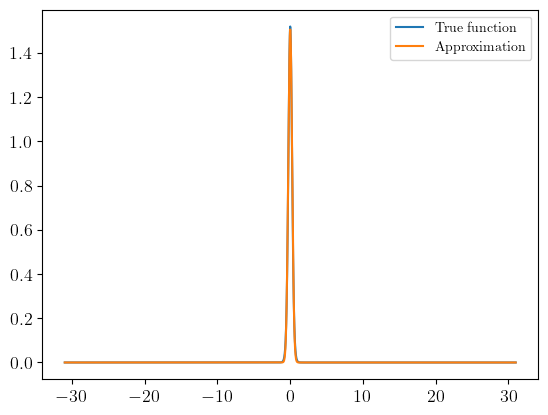

derivative: [2.66890837]


In [52]:
def plot(params, x, w):
    y = model.apply(params, x, mode=evaluationMode.direct)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    plt.plot(x, true_func, label='True function')
    plt.plot(x, approx_func, label='Approximation')
    plt.legend()
    plt.show()

plot(params, x, w)
filename = "simulations_data/lin_algebraic.pkl"
with open(filename, "wb") as f:
    pickle.dump(params, f)

g_deriv = abs_det_jac_x(model, params, jnp.array([0.])[:,None], mode=evaluationMode.direct)
print(f"derivative: {g_deriv}")

filename_save = f"simulations_data/lin_algebraic.npz"
np.savez(filename_save, epochs=n_epochs, losses_nl=losses_nl, sing_loc=g_deriv)

## Learning a super Gaussian function

In [53]:
f = f_super_Gaussian

x = jnp.linspace(-12.999,12.999,10000)

w = np.zeros_like(x)
dx = np.diff(x)
w[1:-1] = (dx[:-1] + dx[1:])/2
w[0] = dx[0]/2
w[-1] = dx[-1]/2
x = x[:,None]

f_ev = f(x, w)
integral = jnp.einsum('j,j->', f_ev, w)
print(f_ev[-1], integral)

0.0 1.0


In [54]:
params = model.init(jax.random.PRNGKey(0), x, mode=evaluationMode.direct)
y_forward = model.apply(params, x, mode=evaluationMode.inverse)
y_forward_back = model.apply(params, y_forward, mode=evaluationMode.direct)

@jax.jit
def l2_error(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values, w))
    return loss

@jax.jit
def error_tail(params, x, w):    
    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    error_values = (true_func - approx_func)**2
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values*(1+x[:,0]**2 / (true_func + 1e-30)), w))
    return loss


def total_loss(params, x, w, alpha=0.3):
    return alpha*l2_error(params, x, w) + (1-alpha)*error_tail(params, x, w)

nograd = lambda x: jax.lax.stop_gradient(x)
loss_grad_fn = jax.value_and_grad(total_loss)
loss_fn = total_loss

@jax.jit
def update_params(carry, args):
    params, opt_state, loss = carry
    loss_val, grad = loss_grad_fn(params, *args)
    updates, opt_state = optimizer.update(grad, opt_state)
    params = optax.apply_updates(params, updates)

    return (params, opt_state, loss+loss_val), 0

learning_rate = 1e-3
n_epochs = 10000

schedule = optax.cosine_decay_schedule(learning_rate, n_epochs, alpha=5e-5/learning_rate)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(schedule),
)
opt_state = optimizer.init(params)
losses_nl = []
for epoch in range(1,n_epochs):
    carry = (params, opt_state, 0)
    carry, _ = update_params(carry, (nograd(x), nograd(w)))
    params, opt_state, loss = carry 
    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
        losses_nl.append(loss)


Epoch: 100, Loss: 12497173676.860401
Epoch: 200, Loss: 1678951813.3462348
Epoch: 300, Loss: 190220861.486555
Epoch: 400, Loss: 18210566.790329583
Epoch: 500, Loss: 1476611.1662381813
Epoch: 600, Loss: 101694.78066714651
Epoch: 700, Loss: 5967.978026577968
Epoch: 800, Loss: 299.6779580392385
Epoch: 900, Loss: 13.100774149006302
Epoch: 1000, Loss: 0.9727061364737323
Epoch: 1100, Loss: 0.8312932448081486
Epoch: 1200, Loss: 0.8312932272041287
Epoch: 1300, Loss: 0.8312932268573733
Epoch: 1400, Loss: 0.831293226857321
Epoch: 1500, Loss: 0.8312932268573205
Epoch: 1600, Loss: 0.8312932268573209
Epoch: 1700, Loss: 0.8312932268573209
Epoch: 1800, Loss: 0.8312932268573209
Epoch: 1900, Loss: 0.8312932268573209
Epoch: 2000, Loss: 0.8312932268573209
Epoch: 2100, Loss: 0.8312932268573209
Epoch: 2200, Loss: 0.8312932268573209
Epoch: 2300, Loss: 0.8312932268573209
Epoch: 2400, Loss: 0.8312932268573209
Epoch: 2500, Loss: 0.8312932268573208
Epoch: 2600, Loss: 0.8312932268573208
Epoch: 2700, Loss: 0.83129

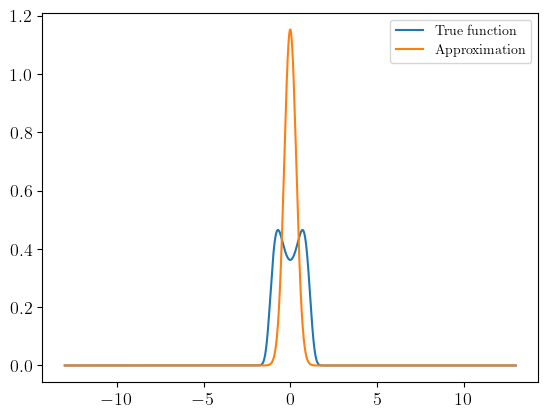

In [55]:
def plot(params, x, w):
    y = model.apply(params, x, mode=evaluationMode.direct)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    true_func = f(x,w)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    
    approx_func = jnp.einsum('j,j->j', Gaussian(y)[:,0], det)
    plt.plot(x, true_func, label='True function')
    plt.plot(x, approx_func, label='Approximation')
    plt.legend()
    plt.show()

plot(params, x, w)
filename = "simulations_data/lin_superGaussian.pkl"
with open(filename, "wb") as f:
    pickle.dump(params, f)

filename_save = f"simulations_data/lin_superGaussian.npz"
np.savez(filename_save, epochs=n_epochs, losses_nl=losses_nl,)

## Approximation using perturbed Hermite

In [56]:
list_decay = ["algebraic", "superGaussian",]
list_filename = ["simulations_data/lin_algebraic.pkl", "simulations_data/lin_superGaussian.pkl",]

In [57]:


def compute_coeff_uj(params, decay):
    
    if decay == "algebraic":
        x = jnp.linspace(-30.999, 30.999, 10000)
        full_f = full_f_algebraic
    elif decay == "superGaussian":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_super_Gaussian
    elif decay == "tanh":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_tanh
    
    w = np.zeros_like(x)
    dx = np.diff(x)
    w[1:-1] = (dx[:-1] + dx[1:])/2
    w[0] = dx[0]/2
    w[-1] = dx[-1]/2
    x = x[:,None]

    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = full_f(x,w)
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    psi_ev = psi_o(y)
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)
    weight = jnp.exp(-y[:,0]**2/2)  
    psi_ev = jnp.einsum('jk,j,j->jk', psi_ev, weight, det)
    approx_coeffs = jnp.einsum('j,jk,j->k', true_func, psi_ev, w)
    return approx_coeffs
   
def l2_error_uj(params, decay):    
    #det = abs_det_jac_x(model, params, r, mode=evaluationMode.direct)
    if decay == "algebraic":
        x = jnp.linspace(-30.999, 30.999, 10000)
        full_f = full_f_algebraic
    elif decay == "superGaussian":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_super_Gaussian
    elif decay == "tanh":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_tanh
    
    w = np.zeros_like(x)
    dx = np.diff(x)
    w[1:-1] = (dx[:-1] + dx[1:])/2
    w[0] = dx[0]/2
    w[-1] = dx[-1]/2
    x = x[:,None]

    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = full_f(x,w)
    psi_ev = psi_o(y) #pr?
    weight = jnp.exp(-y[:,0]**2/2)  
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)

    approx_coeffs = compute_coeff_uj(params, decay)
    approx_func = jnp.einsum('k,jk,j,j->j', approx_coeffs, psi_ev, det, weight)

    error_values = (true_func - approx_func)**2
    #loss = jnp.mean(error_values)
    loss = jnp.sqrt(jnp.einsum('i,i->', error_values, w))
    return loss


def linf_error_uj(params, decay):  
    if decay == "algebraic":
        x = jnp.linspace(-30.999, 30.999, 10000)
        full_f = full_f_algebraic
    elif decay == "superGaussian":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_super_Gaussian
    elif decay == "tanh":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_tanh
    
    w = np.zeros_like(x)
    dx = np.diff(x)
    w[1:-1] = (dx[:-1] + dx[1:])/2
    w[0] = dx[0]/2
    w[-1] = dx[-1]/2
    x = x[:,None]

    y = model.apply(params, x, mode=evaluationMode.direct)
    true_func = full_f(x,w)
    psi_ev = psi_o(y) #pr?
    weight = jnp.exp(-y[:,0]**2/2)  
    det = abs_det_jac_x(model, params, x, mode=evaluationMode.direct)
    det = jnp.sqrt(det)

    approx_coeffs = compute_coeff_uj(params, decay)
    approx_func = jnp.einsum('k,jk,j,j->j', approx_coeffs, psi_ev, det, weight)

    error_values = jnp.abs(true_func - approx_func)
    loss = jnp.amax(error_values)
    return loss

n_values = np.arange(2,48,4)
n_layers = 2

for decay, filename in zip(list_decay, list_filename):
    losses_nl = []
    lossesinf_nl = []
    size_basis = []
    with open(filename, "rb") as f:
        params = pickle.load(f)
        print(f"params:{params} for decay: {decay}")

    model = Lin(x.shape[1])

    for n in n_values:
        nmax = n
        n_basis = [nmax for _ in range(x.shape[1])]
        w_basis = [1 for _ in range(x.shape[1])]
        # Note that when we project we need to multiply by the weights of the basis
      
        basis_r = Hermite.init_basis(n_basis, w_basis, nmax, orthotype=orthoType.ortho) # 
        psi_o = partial(Hermite.batch_basis_values, basis_r)  

        loss = l2_error_uj(params, decay)
        loss_inf = linf_error_uj(params, decay)
        print(f"n: {n}, L2 error: {loss}, Linf error: {loss_inf}")
        losses_nl.append(loss)
        lossesinf_nl.append(loss_inf)
        size_basis.append(n+1)
        #plot_uj(params, x, w)
    np.savez(f"simulations_data/losses_lin_{decay}.npz", size_basis=size_basis, losses_nl=losses_nl, lossesinf_nl=lossesinf_nl)

params:{'params': {'lin_model': {'linear_a': Array([2.66890837], dtype=float64), 'linear_b': Array([-1.62560158e-17], dtype=float64)}}} for decay: algebraic
n: 2, L2 error: 0.026025747764389835, Linf error: 0.03045490715920024
n: 6, L2 error: 0.0031649347836565675, Linf error: 0.0032789304120068915
n: 10, L2 error: 0.0010885123284857202, Linf error: 0.0013232592362356198
n: 14, L2 error: 0.0005691153536472118, Linf error: 0.0006917338685279255
n: 18, L2 error: 0.0003267075824634887, Linf error: 0.00037507882113837457
n: 22, L2 error: 0.00019634622786044248, Linf error: 0.00021204715938811342
n: 26, L2 error: 0.00012200823590127706, Linf error: 0.00012393360612901916
n: 30, L2 error: 7.778373677465746e-05, Linf error: 7.41333451935937e-05
n: 34, L2 error: 5.057063622601069e-05, Linf error: 5.137901715370565e-05
n: 38, L2 error: 3.336975340214122e-05, Linf error: 3.637964779498936e-05
n: 42, L2 error: 2.226977137659977e-05, Linf error: 2.585325434304861e-05
n: 46, L2 error: 1.49993536814

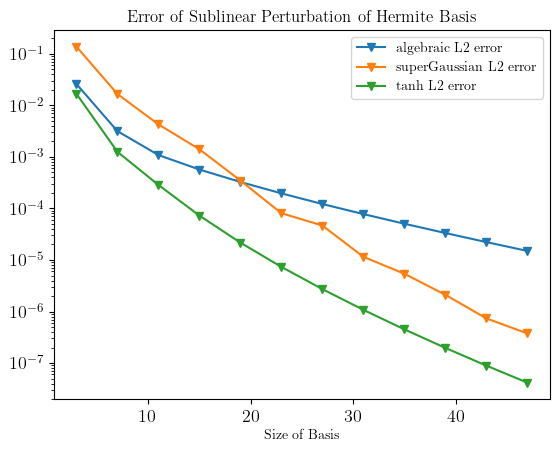

In [58]:
# Let's plot the results
list_decay = ["algebraic", "superGaussian", "tanh"]
for decay in list_decay:
    data = np.load(f"simulations_data/losses_lin_{decay}.npz")
    size_basis = data["size_basis"]
    losses_nl = data["losses_nl"]
    lossesinf_nl = data["lossesinf_nl"]
    plt.plot(size_basis, losses_nl, label=f"{decay} L2 error", marker='v')
    #plt.plot(size_basis, lossesinf_nl, label=f"{decay} Linf error", marker='v')
plt.legend()
plt.yscale('log')
plt.xlabel("Size of Basis")
plt.title("Error of Sublinear Perturbation of Hermite Basis")
plt.show()

In [59]:
filename = "simulations_data/lin_tanh_10.pkl"
with open(filename, "rb") as f:
    loaded_params = pickle.load(f)
print(loaded_params)
y = model.apply(loaded_params, jnp.array([0.]).reshape(-1,1), mode=evaluationMode.inverse)
det = abs_det_jac_x(model, loaded_params, y, mode=evaluationMode.direct)
print(det)
print(jnp.pi/2*(1/det))

{'params': {'lin_model': {'linear_a': Array([1.17814971], dtype=float64), 'linear_b': Array([0.27062479], dtype=float64)}}}
[1.17814971]
[1.33327395]
